In [ ]:
import numpy as np
from math import *
from matplotlib import pyplot as plt

def ToCartesian(angles, l1=30, l2=33):
    """
    Converts joint angles to Cartesian coordinates.

    Parameters:
        angles (list or array): Joint angles [theta1, theta2] in radians.
        l1 (float): Length of the first link.
        l2 (float): Length of the second link.

    Returns:
        (x, y): Cartesian coordinates of the end effector.
    """
    theta1, theta2 = angles
    x = l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2)
    y = l1 * np.sin(theta1) + l2 * np.sin(theta1 + theta2)
    return x, y

I1 = 0.025
I2 = 0.045
m1 = 1.4
m2 = 1
l1 = 0.3
l2 = 0.33
s1 = 0.11
s2 = 0.16
K = 1 / 0.06
tau = 0.06


a1 = I1 + I2 + m2 * l1 * l1
a2 = m2 * l1 * s2
a3 = I2

Viscous = np.array([[0.05, 0.025], [0.025, 0.05]])

def Linearization(x,N = 8):
    TimeConstant = 1 / 0.06  # Torque dynamics coefficient

    # Extract state variables according to the given order
    theta1, theta2, dtheta1, dtheta2, tau1, tau2 = x[:6]

    # Coriolis force
    C = np.array([
        -dtheta2 * (2 * dtheta1 + dtheta2) * a2 * np.sin(theta2),
        dtheta1**2 * a2 * np.sin(theta2)
    ])
    
    # Partial derivatives of C
    dCdte = np.array([
        -dtheta2 * (2 * dtheta1 + dtheta2) * a2 * np.cos(theta2),
        dtheta1**2 * a2 * np.cos(theta2)
    ])
    dCdos = np.array([
        -dtheta2 * 2 * a2 * np.sin(theta2),
        2 * dtheta1 * a2 * np.sin(theta2)
    ])
    dCdoe = np.array([
        (-2 * dtheta1 - 2 * dtheta2) * a2 * np.sin(theta2),
        0
    ])
    
    # Inertia matrix
    M = np.array([
        [a1 + 2 * a2 * np.cos(theta2), a3 + a2 * np.cos(theta2)],
        [a3 + a2 * np.cos(theta2), a3]
    ])
    
    Minv = np.linalg.inv(M)
    
    # Derivative of inertia matrix
    dM = np.array([
        [-2 * a2 * np.sin(theta2), -a2 * np.sin(theta2)],
        [-a2 * np.sin(theta2), 0]
    ])
    
    # Compute acceleration dependencies
    dtheta = np.array([dtheta1, dtheta2])
    tau = np.array([tau1, tau2])

    d_accel_dtheta1 = -Minv @ (dCdos + Viscous @ np.array([1, 0]))
    d_accel_tau = Minv @ np.array([1, 0])
    d_accel_theta2 = -Minv @ (dM @ Minv @ (tau - C - Viscous @ dtheta)) - Minv @ dCdte
    d_accel_dtheta2 = -Minv @ (dCdoe + Viscous @ np.array([0, 1]))
    d_accel_tau2 = Minv @ np.array([0, 1])

    # Construct the Jacobian matrix
    A = np.zeros((N,N))

    # Assign known structure
    A[0, 2] = 1  # d(theta1)/d(dtheta1)
    A[1, 3] = 1  # d(theta2)/d(dtheta2)

    # Acceleration contributions
    A[2, 2] = d_accel_dtheta1[0]  # d(dtheta1)/d(dtheta1)
    A[2, 1] = d_accel_theta2[0]
    A[2, 3] = d_accel_dtheta2[0]  # d(dtheta1)/d(dtheta2)
    A[2, 4] = d_accel_tau[0]  # d(dtheta1)/d(tau1)
    A[2, 5] = d_accel_tau2[0]  # d(dtheta1)/d(tau2)

    A[3, 2] = d_accel_dtheta1[1]  # d(dtheta2)/d(dtheta1)
    A[3, 1] = d_accel_theta2[1]
    A[3, 3] = d_accel_dtheta2[1]  # d(dtheta2)/d(dtheta2)
    A[3, 4] = d_accel_tau[1]  # d(dtheta2)/d(tau1)
    A[3, 5] = d_accel_tau2[1]  # d(dtheta2)/d(tau2)

    # Torque dynamics
    A[4, 4] = -TimeConstant
    A[5, 5] = -TimeConstant

    return A

def f(x, u):
    tau = 0.06
    C = np.array(
        [-x[3] * (2 * x[2] + x[3]) * a2 * np.sin(x[1]), x[2] * x[2] * a2 * np.sin(x[1])]
    )
    Denominator = a3 * (a1 - a3) - a2 * a2 * np.cos(x[1]) * np.cos(x[1])
    Minv = np.array(
        [
            [a3 / Denominator, (-a2 * np.cos(x[1]) - a3) / Denominator],
            [
                (-a2 * np.cos(x[1]) - a3) / Denominator,
                (2 * a2 * np.cos(x[1]) + a1) / Denominator,
            ],
        ]
    )
    theta = Minv @ (x[4:6] - Viscous @ x[2:4] - C)
    torque = (u - x[4:6]) / tau
    return np.array([[x[2], x[3], theta[0], theta[1], torque[0], torque[1],0,0]])


def fx(x, u):
    return Linearization(x)


def fu():
    tau = 0.06
    return np.array([[0, 0], [0, 0], [0, 0], [0, 0], [1 / tau, 0], [0, 1 / tau]])

def compute_angles_from_cartesian(x, y, l1=30, l2=33):
    """
    Computes joint angles in radians based on cartesian coordinates.

    Parameters:
        x (float): x-coordinate of the end effector.
        y (float): y-coordinate of the end effector.
        l1 (float): Length of the first link.
        l2 (float): Length of the second link.

    Returns:
        angles (float): Computed angle in radians.
    """
    r_squared = x**2 + y**2

    shoulder_angle = np.arctan2(y, x) - np.arccos(
        (r_squared + l1**2 - l2**2) / (2 * l1 * np.sqrt(r_squared))
    )

    elbow_angle = np.pi - np.arccos((l1**2 + l2**2 - r_squared) / (2 * l1 * l2))
    return shoulder_angle, elbow_angle

def compute_forcefield(theta, omega, acc, coefficient):
    """
    Compute the joint angles acceleration resulting from a lateral
    velocity-dependent forcefield.

    Args:
        theta : current joint angles
        omega : current joint angular velocities
        acc : current joint angular accelerations
        coefficient : Multiplier coefficient on the force field such that yddot = 13 * coeff * xdot

    """
    t0, t1 = theta
    o0, o1 = omega
    sin_t0, cos_t0 = np.sin(t0), np.cos(t0)
    sin_t01, cos_t01 = np.sin(t0 + t1), np.cos(t0 + t1)

    fe = -33 * sin_t01
    fs = fe - 30 * sin_t0
    ge = 33 * cos_t01
    gs = ge + 30 * cos_t0

    fse = -33 * cos_t01
    gse = -33 * sin_t01
    fee = fse
    fss = fse - 30 * cos_t0
    gee = fe
    gss = fs

    xddot = (
        13 * (gs * o0 + ge * o1) * coefficient
        + fss * o0 * o0
        + 2 * fse * o0 * o1
        + fee * o1 * o1
        + fs * acc[0]
        + fe * acc[1]
    )
    yddot = (
        gss * o0 * o0 + 2 * gse * o0 * o1 + gee * o1 * o1 + gs * acc[0] + ge * acc[1]
    )

    gamma = xddot - fss * o0 * o0 - 2 * fse * o0 * o1 - fee * o1 * o1
    nu = yddot - gss * o0 * o0 - 2 * gse * o0 * o1 - gee * o1 * o1
    F1 = (fe * nu - ge * gamma) / (fe * gs - ge * fs) - acc[0]
    F2 = (gs * gamma - fs * nu) / (gs * fe - ge * fs) - acc[1]
    return np.array([F1, F2])

def CRAP(
    Duration=0.6,
    w1=1e4,
    w2=1e4,
    w3=1,
    w4=1,
    r1=1e-8,
    targets=[0, 55],
    starting_point=[0, 20],
    plot=True,
    Delay=0,
    Num_iter=60,
    Activate_Noise=False,
    motornoise_variance=1e-3,
    ClassicLQG=False,
    FF=False,
    ff_power=0.3,
):

    dt = Duration / Num_iter
    kdelay = int(Delay / dt)
    obj1, obj2 = compute_angles_from_cartesian(targets[0],targets[1])  # Defini les targets
    st1, st2 = compute_angles_from_cartesian(starting_point[0],starting_point[1])  # Defini le point de depart

    x0 = np.array([st1, st2, 0, 0,0,0, obj1, obj2])
    x0_with_delay = np.tile(x0, kdelay + 1)
    Num_Var = 8

    R = np.diag(np.ones(2) * r1)

    Q = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    Q[:Num_Var, :Num_Var] = np.array(
        [
            [w1, 0, 0, 0,0,0, -w1, 0],
            [0, w2, 0, 0,0,0, 0, -w2],
            [0, 0, w3, 0, 0, 0,0,0],
            [0, 0, 0, w4, 0, 0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [-w1, 0, 0, 0,0,0, w1, 0],
            [0, -w2, 0, 0, 0,0,0, w2],
        ]
    )

    H = np.zeros((Num_Var, (kdelay + 1) * Num_Var))
    H[:, (kdelay) * Num_Var :] = np.identity(Num_Var)

    A = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    A[Num_Var:, :-Num_Var] = np.identity((kdelay) * Num_Var)

    B = np.zeros(((kdelay + 1) * Num_Var, 2))
    B[:6] = dt * fu()
    array_x = np.zeros((Num_iter, Num_Var))
    array_xhat = np.zeros((Num_iter, Num_Var))
    array_u = np.zeros((Num_iter - 1, 2))
    y = np.zeros((Num_iter - 1, Num_Var))

    array_x[0] = x0.flatten()
    array_xhat[0] = x0.flatten()

    xhat = np.copy(x0_with_delay)
    x = np.copy(x0_with_delay)

    sigma = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
    J = 0
    u = np.zeros(2)
    for k in range(Num_iter - 1):
        if k != 0:
            acc = (f(x[:Num_Var], u)[:, 2:4] + F).reshape(2)
        else:
            acc = np.zeros(2)
        F = (
            compute_forcefield(x[0:2], x[2:4], acc, ff_power)
            if FF == True
            else np.array([0, 0])
        )

        xcopy = np.copy(xhat)
        xcopy[2:8] = 0
        A[:Num_Var, :Num_Var] = np.identity(8)+dt*Linearization(xcopy)
        

        S = Q
        for _ in range(Num_iter - 1 - k):
            L = np.linalg.inv(R + B.T @ S @ B) @ B.T @ S @ A
            S = A.T @ S @ (A - B @ L)
        u = -L @ xhat
        J += u.T @ R @ u

        Omega_motor = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
        Omega_measure = np.diag(np.ones(Num_Var) * 1e-4)
        for i in range(4,6):

            Omega_motor[i, i] = motornoise_variance
        y[k] = (H @ x).flatten()
        if Activate_Noise == True:
            y[k] += np.random.normal(0, 1e-2, Num_Var)

        K = A @ sigma @ H.T @ np.linalg.inv(H @ sigma @ H.T + Omega_measure)
        sigma = Omega_motor + (A - K @ H) @ sigma @ A.T

        xhat = A @ xhat + B @ u + K @ (y[k] - H @ xhat)

        x_new = (x[:Num_Var] + dt * (f(x, u))).reshape(Num_Var)
        x_new[2:4] += dt * F

        # Concatenate with remaining x values
        x = np.concatenate((x_new, x[:-Num_Var]))

        if Activate_Noise:

            x[[4,5]] += np.random.normal(0, np.sqrt(motornoise_variance), 2)

        array_xhat[k + 1] = xhat[:Num_Var].flatten()
        array_x[k + 1] = x[:Num_Var].flatten()
        array_u[k] = u

        # print(array_x[k-1,2],((array_x[k]-array_x[k-1])/dt)[1])

    # Plot
    J += x.T @ Q @ x

    x_nonlin = array_x.T[:, :][:, ::1]
    X = np.cos(x_nonlin[0] + x_nonlin[1]) * 33 + np.cos(x_nonlin[0]) * 30
    Y = np.sin(x_nonlin[0] + x_nonlin[1]) * 33 + np.sin(x_nonlin[0]) * 30

    if plot:
        color = "magenta" if ClassicLQG else "green"
        label = "LQG" if ClassicLQG else "DLQG"
        plt.plot(X, Y, color=color, label=label, linewidth=0.8)
        plt.axis("equal")
        tg = np.array([obj1, obj2])
        plt.scatter(
            np.array([ToCartesian(tg)[0]]),
            np.array([ToCartesian(tg)[1]]),
            color="black",
        )
        plt.show()
    return X, Y, array_u, x_nonlin

[0.62848098 1.76854731 0.         0.         0.         0.
 0.         0.        ]
0
[0.62848098 1.76854731 0.         0.         0.         0.
 0.         0.        ]
1
[0.62848098 1.76854731 0.         0.         0.         0.
 0.         0.        ]
2
[0.62857931 1.76836105 0.         0.         0.         0.
 0.         0.        ]
3
[0.62885386 1.76784159 0.         0.         0.         0.
 0.         0.        ]
4
[0.62936548 1.7668746  0.         0.         0.         0.
 0.         0.        ]
5
[0.63016087 1.76537275 0.         0.         0.         0.
 0.         0.        ]
6
[0.63127503 1.76327095 0.         0.         0.         0.
 0.         0.        ]
7
[0.63273325 1.76052243 0.         0.         0.         0.
 0.         0.        ]
8
[0.63455273 1.75709551 0.         0.         0.         0.
 0.         0.        ]
9
[0.63674401 1.75297095 0.         0.         0.         0.
 0.         0.        ]
10
[0.63931206 1.74813978 0.         0.         0.         0.
 0.  

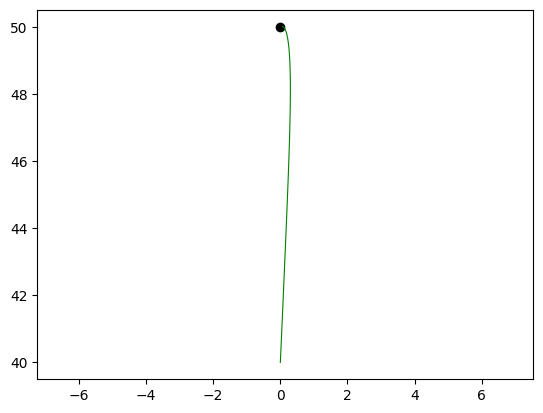

(array([1.77635684e-14, 1.77635684e-14, 1.77635684e-14, 2.31743672e-04,
        8.66144339e-04, 2.02544516e-03, 3.79384432e-03, 6.22635406e-03,
        9.35593462e-03, 1.31990777e-02, 1.77600654e-02, 2.30341371e-02,
        2.90097755e-02, 3.56702991e-02, 4.29949122e-02, 5.09593377e-02,
        5.95361299e-02, 6.86947441e-02, 7.84014238e-02, 8.86189509e-02,
        9.93062961e-02, 1.10418202e-01, 1.21904721e-01, 1.33710735e-01,
        1.45775472e-01, 1.58032049e-01, 1.70407053e-01, 1.82820186e-01,
        1.95183997e-01, 2.07403717e-01, 2.19377234e-01, 2.30995214e-01,
        2.42141419e-01, 2.52693219e-01, 2.62522351e-01, 2.71495931e-01,
        2.79477757e-01, 2.86329920e-01, 2.91914746e-01, 2.96097085e-01,
        2.98746963e-01, 2.99742611e-01, 2.98973867e-01, 2.96345949e-01,
        2.91783600e-01, 2.85235574e-01, 2.76679455e-01, 2.66126765e-01,
        2.53628331e-01, 2.39279883e-01, 2.23227832e-01, 2.05675213e-01,
        1.86887809e-01, 1.67200527e-01, 1.47024270e-01, 1.268539

In [29]:
CRAP(r1 = 1e-6,starting_point=[0,40],targets=[0,50])